# Group Details

**Group ID:**
4
**Group name:**

**Group members that contributed to the assignment (full name): **
- Lise Katrine Arnesen, bvh426
- Thomas Andersen, kgq325

In [1]:
%load_ext autoreload
%autoreload 2
import os
print(os.getcwd())
to_run = True
if to_run:
    os.chdir('..')
    to_run = False
print(os.getcwd())

/workspaces/codespaces-jupyter/pm4py-dcr-feature-dcr_in_pm4py_revised/A2
/workspaces/codespaces-jupyter/pm4py-dcr-feature-dcr_in_pm4py_revised


In [2]:
import csv
import pandas as pd
import numpy as np
import pm4py    
import datetime
from pm4py.objects.dcr.obj import DcrGraph
from pm4py.objects.log.obj import EventLog, Trace, Event

# Part 1

### Log

In [ ]:
## Code for part 1
with open('A2/log_part_1_2.csv', 'r') as file:
    csv_reader = csv.reader(file)
    csv_log = list(csv_reader)

# Define valid events
valid_events = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]

# Function to structure the log
def structure_log(csv_log, valid_events):
    structured_log = []
    for i, row in enumerate(csv_log):
        # Strip whitespace from each element
        cleaned_row = [activity.strip() for activity in row]
        # Check if all events are valid
        if all(event in valid_events for event in cleaned_row):
            structured_log.append(cleaned_row)
        else:
            invalid_events = [event for event in cleaned_row if event not in valid_events]
            print(f"Row {i} includes invalid activity {invalid_events} and is excluded")
    return structured_log

# Function to transform structured log to EventLog
def transform_to_event_log(structured_log):
    log = EventLog()
    for trace_data in structured_log:
        trace = Trace(attributes={"concept:name": f"{trace_data}"})
        for event_name in trace_data:
            trace.append(Event({"concept:name": event_name, "time:timestamp": datetime.datetime.now()}))
        log.append(trace)
    return log

In [4]:
structured_log = structure_log(csv_log, valid_events)
log = transform_to_event_log(structured_log)

### Models

Number of fitting traces: 40


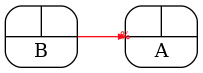

In [5]:
model_1 = DcrGraph()

events = ["A", "B"]

for event in events:
    model_1.events.add(event)
    model_1.labels.add(event)
    model_1.label_map[event] = event

for event in model_1.events:
    model_1.marking.included.add(event)

model_1.excludes["B"] = {"A"}

res = pm4py.conformance_dcr(log = log, dcr_graph = model_1)
fit_count = sum(1 for trace_result in res if trace_result["is_fit"])
print(f"Number of fitting traces: {fit_count}")

# TODO: Remove before handin
pm4py.view_dcr(model_1)

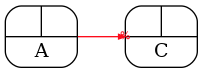

In [6]:
model_2 = DcrGraph()
events = ["A", "C"]

for event in events:
    model_2.events.add(event)
    model_2.labels.add(event)
    model_2.label_map[event] = event

for event in model_2.events:
    model_2.marking.included.add(event)

model_2.excludes["A"] = {"C"}

# TODO: Remove before handin
pm4py.view_dcr(model_2)

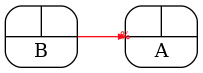

In [7]:
model_3 = DcrGraph()
events = ["A", "B"]

for event in events:
    model_3.events.add(event)
    model_3.labels.add(event)
    model_3.label_map[event] = event

for event in model_3.events:
    model_3.marking.included.add(event)

model_3.excludes["B"] = {"A"}

# TODO: Remove before handin
pm4py.view_dcr(model_3)

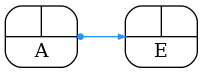

In [8]:
model_4 = DcrGraph()
events = ["A", "E"]

for event in events:
    model_4.events.add(event)
    model_4.labels.add(event)
    model_4.label_map[event] = event

for event in model_4.events:
    model_4.marking.included.add(event)

model_4.responses["A"] = {"E"}

# TODO: Remove before handin
pm4py.view_dcr(model_4)

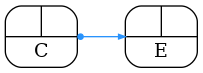

In [9]:
model_5 = DcrGraph()
events = ["C", "E"]

for event in events:
    model_5.events.add(event)
    model_5.labels.add(event)
    model_5.label_map[event] = event

for event in model_5.events:
    model_5.marking.included.add(event)

model_5.responses["C"] = {"E"}

# TODO: Remove before handin
pm4py.view_dcr(model_5)

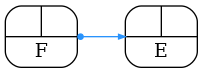

In [10]:
model_6 = DcrGraph()
events = ["E", "F"]

for event in events:
    model_6.events.add(event)
    model_6.labels.add(event)
    model_6.label_map[event] = event

for event in model_6.events:
    model_6.marking.included.add(event)

model_6.responses["F"] = {"E"}

# TODO: Remove before handin
pm4py.view_dcr(model_6)

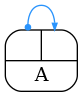

In [11]:
model_7 = DcrGraph()
events = ["A"]

for event in events:
    model_7.events.add(event)
    model_7.labels.add(event)
    model_7.label_map[event] = event

for event in model_7.events:
    model_7.marking.included.add(event)

model_7.responses["A"] = {"A"}
# TODO: Remove before handin

pm4py.view_dcr(model_7)

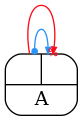

In [12]:
model_8 = DcrGraph()
events = ["A"]

for event in events:
    model_8.events.add(event)
    model_8.labels.add(event)
    model_8.label_map[event] = event

for event in model_8.events:
    model_8.marking.included.add(event)

model_8.responses["A"] = {"A"}
model_8.excludes["A"]  = {"A"}

# TODO: Remove before handin
pm4py.view_dcr(model_8)

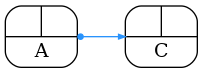

In [13]:
model_9 = DcrGraph()
events = ["A", "C"]

for event in events:
    model_9.events.add(event)
    model_9.labels.add(event)
    model_9.label_map[event] = event

for event in model_9.events:
    model_9.marking.included.add(event)

model_9.responses["A"] = {"C"}

# TODO: Remove before handin
pm4py.view_dcr(model_9)

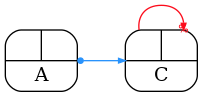

In [14]:
model_10 = DcrGraph()
events = ["A", "C"]

for event in events:
    model_10.events.add(event)
    model_10.labels.add(event)
    model_10.label_map[event] = event

for event in model_10.events:
    model_10.marking.included.add(event)

model_10.responses["A"] = {"C"}
model_10.excludes["C"] = {"C"}

# TODO: Remove before handin
pm4py.view_dcr(model_10)

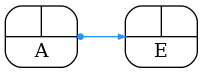

In [15]:
model_11 = DcrGraph()
events = ["A", "E"]

for event in events:
    model_11.events.add(event)
    model_11.labels.add(event)
    model_11.label_map[event] = event

for event in model_11.events:
    model_11.marking.included.add(event)

model_11.responses["A"] = {"E"}

# TODO: Remove before handin
pm4py.view_dcr(model_11)

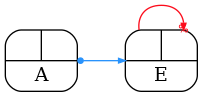

In [16]:
model_12 = DcrGraph()
events = ["A", "E"]

for event in events:
    model_12.events.add(event)
    model_12.labels.add(event)
    model_12.label_map[event] = event

for event in model_12.events:
    model_12.marking.included.add(event)

model_12.responses["A"] = {"E"}
model_12.excludes["E"] = {"E"}

# TODO: Remove before handin
pm4py.view_dcr(model_12)

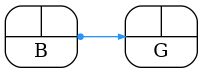

In [17]:
model_13 = DcrGraph()
events = ["B", "G"]

for event in events:
    model_13.events.add(event)
    model_13.labels.add(event)
    model_13.label_map[event] = event

for event in model_13.events:
    model_13.marking.included.add(event)

model_13.responses["B"] = {"G"}

# TODO: Remove before handin
pm4py.view_dcr(model_13)

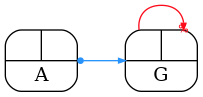

In [18]:
model_14 = DcrGraph()
events = ["A", "G"]

for event in events:
    model_14.events.add(event)
    model_14.labels.add(event)
    model_14.label_map[event] = event

for event in model_14.events:
    model_14.marking.included.add(event)

model_14.responses["A"] = {"G"}
model_14.excludes["G"] = {"G"}

# TODO: Remove before handin
pm4py.view_dcr(model_14)

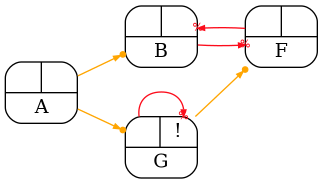

In [19]:
model_15 = DcrGraph()
events = ["A", "B", "F", "G"]

for event in events:
    model_15.events.add(event)
    model_15.labels.add(event)
    model_15.label_map[event] = event

for event in model_15.events:
    model_15.marking.included.add(event)

model_15.conditions["B"] = {"A"}
model_15.conditions["G"] = {"A"}
model_15.conditions["F"] = {"G"}

model_15.excludes["F"] = {"B"}
model_15.excludes["B"] = {"F"}
model_15.excludes["G"] = {"G"}

model_15.marking.pending.add("G")

# TODO: Remove before handin
pm4py.view_dcr(model_15)

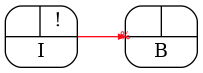

In [20]:
model_16 = DcrGraph()
events = ["B", "I"]

for event in events:
    model_16.events.add(event)
    model_16.labels.add(event)
    model_16.label_map[event] = event

for event in model_16.events:
    model_16.marking.included.add(event)

model_16.excludes["I"] = {"B"}
model_16.marking.pending.add("I")

# TODO: Remove before handin
pm4py.view_dcr(model_16)

In [21]:
conformance_count = []
file = open('A2/solution-part1.txt', 'w')
    
for model_num in range(1, 17):
    try:
        model = eval(f"model_{model_num}")
        res = pm4py.conformance_dcr(log=log, dcr_graph=model)
        fit_count = sum(1 for trace_result in res if trace_result["is_fit"])
        conformance_count.append(fit_count)
        file.writelines(str(fit_count) + '\n')
        print(f"Model {model_num}: {fit_count} fitting traces")
    except NameError:
        print(f"Model {model_num} not defined, skipping...")
        break
file.close()

Model 1: 40 fitting traces
Model 2: 24 fitting traces
Model 3: 40 fitting traces
Model 4: 17 fitting traces
Model 5: 37 fitting traces
Model 6: 33 fitting traces
Model 7: 41 fitting traces
Model 8: 40 fitting traces
Model 9: 17 fitting traces
Model 10: 17 fitting traces
Model 11: 17 fitting traces
Model 12: 17 fitting traces
Model 13: 41 fitting traces
Model 14: 41 fitting traces
Model 15: 33 fitting traces
Model 16: 34 fitting traces


# Part 2

In [22]:
## Code for part 2
Condition_relation = []
file_part2 = open('A2/solution-part2.txt', 'w')

for i in range(0, len(valid_events)):
    for j in range(0, len(valid_events)):
        if i == j:
            continue
        
        # Check ordering of events
        condition_violation = 0
        for k in range(0, len(structured_log)):
            trace = structured_log[k]
            if valid_events[i] in trace and valid_events[j] in trace:
                index_i = trace.index(valid_events[i])
                index_j = trace.index(valid_events[j])
                if index_i >= index_j:
                    condition_violation = condition_violation + 1
        
        # Write to file if no trace is invalid
        if condition_violation == 0:
            file_part2.writelines(f"{valid_events[i]}, {valid_events[j]} \n")  
        
file_part2.close()

# Part 3

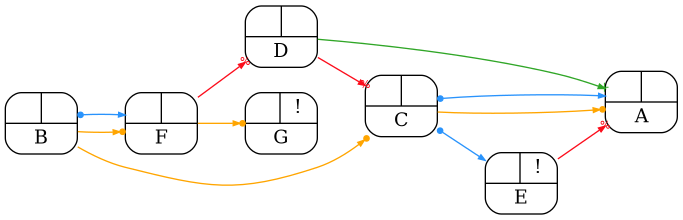

In [23]:
## Code for part 3
with open('A2/log_part_3.csv', 'r') as file:
    csv_reader = csv.reader(file)
    csv_log_part3 = list(csv_reader)

events = ["A", "B", "C", "D", "E", "F", "G"]

model = DcrGraph()

for event in events:
    model.events.add(event)
    model.labels.add(event)
    model.label_map[event] = event

for event in model.events:
    model.marking.included.add(event)

# Conditions
model.conditions["F"] = {"B"}
model.conditions["C"] = {"B"}
model.conditions["A"] = {"C"}
model.conditions["G"] = {"F"}

# Responses
model.responses["B"] = {"F"}
model.responses["C"] = {"A", "E"}

# Excludes
model.excludes["D"] = {"C"}
model.excludes["E"] = {"A"}
model.excludes["F"] = {"D"}

# Includes
model.includes["D"] = {"A"}

# Marking
model.marking.pending.add("E")
model.marking.pending.add("G")

pm4py.view_dcr(model)

In [24]:
# Create EventLog
structured_log_part3 = structure_log(csv_log_part3, events)
log_part3 = transform_to_event_log(structured_log_part3)

In [25]:
# Compute optimal alignment using method from pm4py
res = pm4py.optimal_alignment_dcr(log=log_part3, dcr_graph=model)

# Write alignments to file
file_part3 = open('A2/solution-part3.txt', 'w')

for idx, trace_result in enumerate(res):
    for e_idx, (log_move, model_move) in enumerate(trace_result['alignment']):
        prefix = "" if e_idx == 0 else ", "
        postfix = f"\n" if e_idx == len(trace_result['alignment']) - 1 else ""
        if log_move == model_move:
            file_part3.write(f"{prefix}SYNC({log_move}){postfix}")
        elif log_move == ">>":
            file_part3.write(f"{prefix}DELETE({model_move}){postfix}")
        elif model_move == ">>":
            file_part3.write(f"{prefix}INSERT({log_move}){postfix}")
        
file_part3.close()